<a href="https://colab.research.google.com/github/ariefpurnamamuharram/ariefpurnamamuharram.github.io/blob/master/files/IF6171_23521013_AriefPurnamaMuharram_Praktikum4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum IF5171 - Feed Forward Neural Network (FFNN)
___
Name: Arief Purnama Muharram<br>
Student number: 23521013

## Step 0: Prerequisites
___

### 0.1: Mount Google Drive

In [ ]:
from google.colab import drive


drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


### 0.2: Install required packages

In [ ]:
!pip install numpy
!pip install seaborn
!pip install scikit-learn

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import numpy as np
import seaborn as sns
import sklearn


print('NumPy version:', np.__version__)
print('Seaborn version:', sns.__version__)
print('Scikit-learn version:', sklearn.__version__)

NumPy version: 1.21.6
Seaborn version: 0.11.2
Scikit-learn version: 1.0.2


## Step 1: Dataset Preparation
___

### 1.1: Load dataset

In [ ]:
import pandas as pd


dataset = pd.read_csv('/content/drive/MyDrive/weatherAUS.csv')
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

There are 21 attributes with 1 target attribut (RainTomorrow) on the dataset. Most of data may contain missing values so it may need some degree of missing value handling before further processing.

In [ ]:
dataset.head(3)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No


In [ ]:
dataset.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


### 1.2: Dataset preprocessing

#### A: Null checking

In [ ]:
dataset.isnull().any().any()

True

Okay, confirm there are missing values in the dataset.

In [ ]:
dataset.isnull().any()

Date             False
Location         False
MinTemp           True
MaxTemp           True
Rainfall          True
Evaporation       True
Sunshine          True
WindGustDir       True
WindGustSpeed     True
WindDir9am        True
WindDir3pm        True
WindSpeed9am      True
WindSpeed3pm      True
Humidity9am       True
Humidity3pm       True
Pressure9am       True
Pressure3pm       True
Cloud9am          True
Cloud3pm          True
Temp9am           True
Temp3pm           True
RainToday         True
RainTomorrow      True
dtype: bool

Bacause the size of the dataset is large, so prefer to drop the data that have missing values. I think dropping some (or many) data in this case does not affect the dataset significantly.

In [ ]:
dataset.dropna(how='any', inplace=True)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 56420 entries, 6049 to 142302
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           56420 non-null  object 
 1   Location       56420 non-null  object 
 2   MinTemp        56420 non-null  float64
 3   MaxTemp        56420 non-null  float64
 4   Rainfall       56420 non-null  float64
 5   Evaporation    56420 non-null  float64
 6   Sunshine       56420 non-null  float64
 7   WindGustDir    56420 non-null  object 
 8   WindGustSpeed  56420 non-null  float64
 9   WindDir9am     56420 non-null  object 
 10  WindDir3pm     56420 non-null  object 
 11  WindSpeed9am   56420 non-null  float64
 12  WindSpeed3pm   56420 non-null  float64
 13  Humidity9am    56420 non-null  float64
 14  Humidity3pm    56420 non-null  float64
 15  Pressure9am    56420 non-null  float64
 16  Pressure3pm    56420 non-null  float64
 17  Cloud9am       56420 non-null  float64
 18  Cl

After cleaning the missing values, there are 56420 data that undergoes further analysis.

#### B: Dataset transformation

Transform the target attribute values into a kind numerical representation.

In [ ]:
dict_raintomorrow = {
    'Yes': 1,
    'No': 0
}


dataset['RainTomorrow'] = dataset['RainTomorrow'].apply(lambda x: dict_raintomorrow[x])

### 1.3: Data visualization

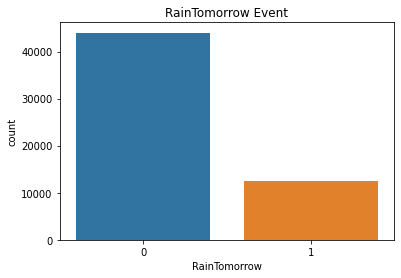

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure()
sns.countplot(data=dataset, x='RainTomorrow')
plt.title('RainTomorrow Event')
plt.show()

Warning! Imbalance dataset. But, let's try!

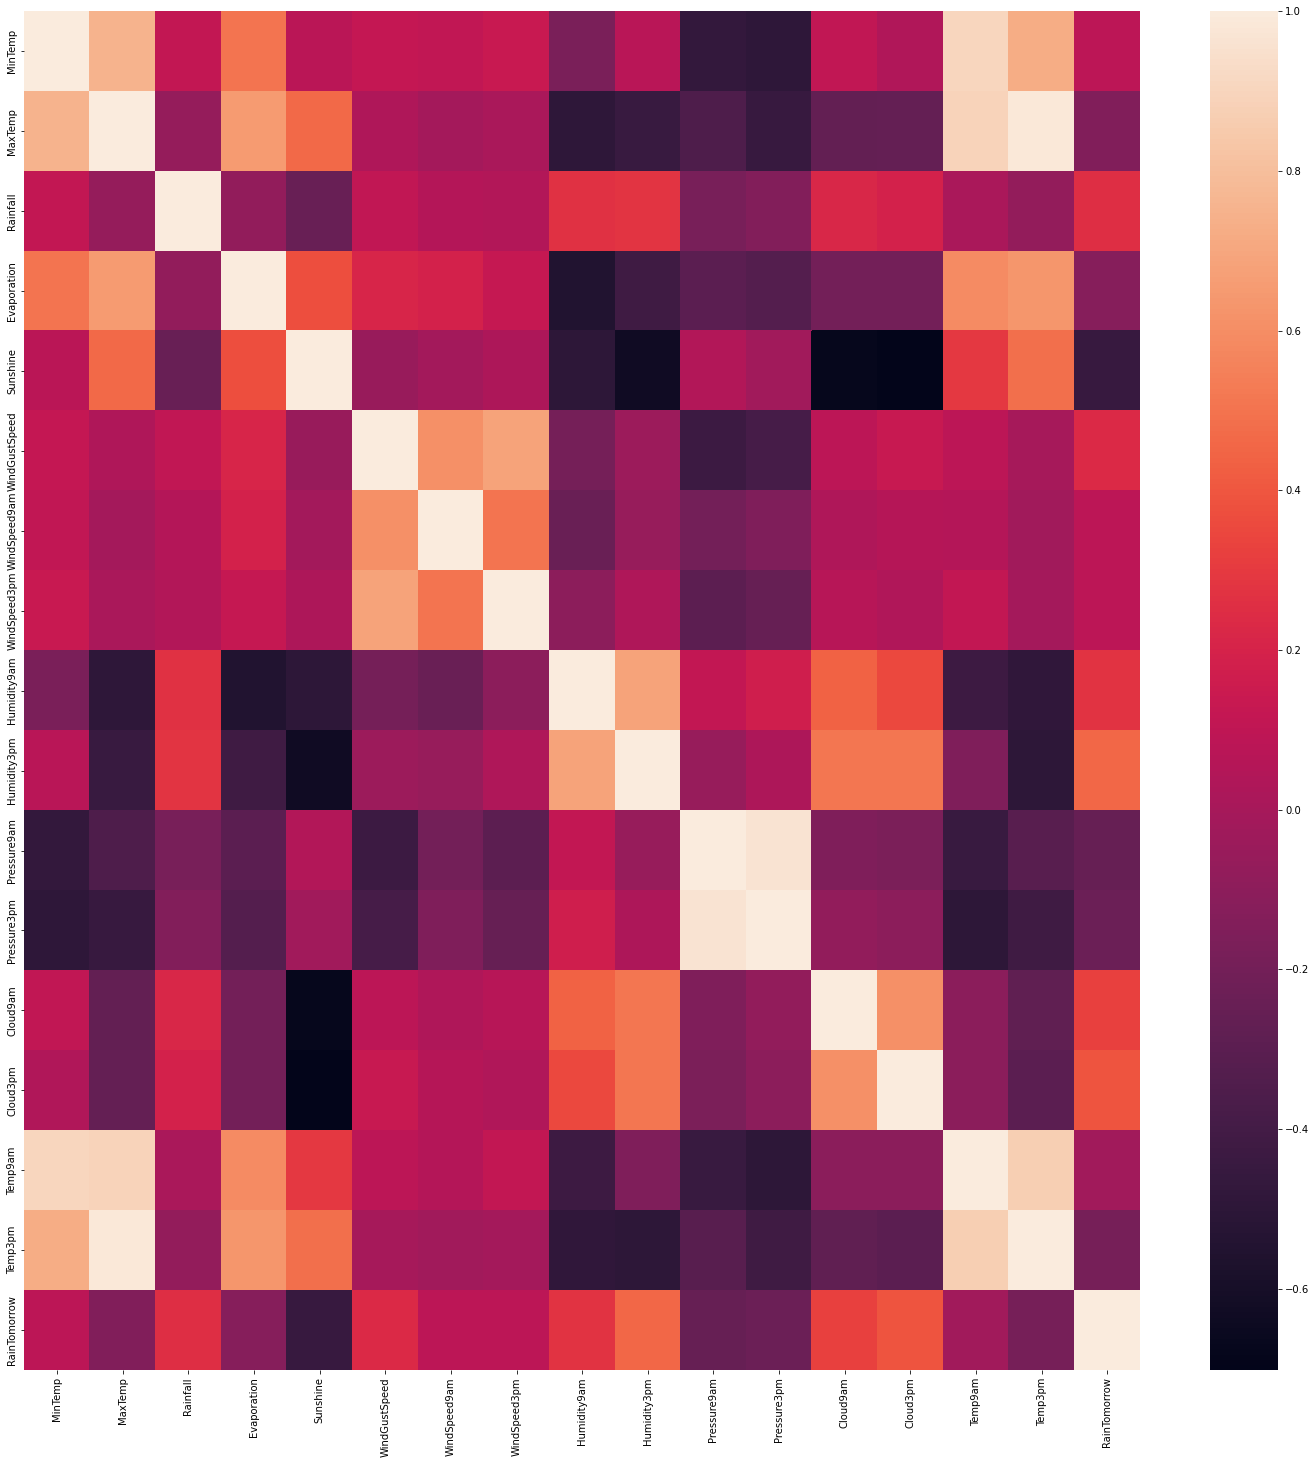

In [ ]:
import seaborn as sns


plt.figure(figsize=(25,25))
sns.heatmap(data=dataset.corr())
plt.show()

This is the correlation matrix!

### 1.4: Train-test split

Although correlation matrix may describe which features need to be included in the further analysis, I prefer to include all non-object attribute data. We hope by including all of the non-object attribute data we can get the good performance of the model.

In [ ]:
dataset.drop(columns=['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday'], inplace=True)

dataset.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 56420 entries, 6049 to 142302
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MinTemp        56420 non-null  float64
 1   MaxTemp        56420 non-null  float64
 2   Rainfall       56420 non-null  float64
 3   Evaporation    56420 non-null  float64
 4   Sunshine       56420 non-null  float64
 5   WindGustSpeed  56420 non-null  float64
 6   WindSpeed9am   56420 non-null  float64
 7   WindSpeed3pm   56420 non-null  float64
 8   Humidity9am    56420 non-null  float64
 9   Humidity3pm    56420 non-null  float64
 10  Pressure9am    56420 non-null  float64
 11  Pressure3pm    56420 non-null  float64
 12  Cloud9am       56420 non-null  float64
 13  Cloud3pm       56420 non-null  float64
 14  Temp9am        56420 non-null  float64
 15  Temp3pm        56420 non-null  float64
 16  RainTomorrow   56420 non-null  int64  
dtypes: float64(16), int64(1)
memory usage: 9.8 MB


In [ ]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    dataset.drop(columns=['RainTomorrow']), dataset['RainTomorrow'], test_size=0.2
)

X_test, X_val, y_test, y_val = train_test_split(
    X_test, y_test, test_size=0.5
)

We use hold out validation scheme for test the model. We use 8:1:1 train-validation-test dataset.

## Step 2: Model Training
___

Because limited of time given, I only try to do experiment on MLP classifier with 2 configurations: one with SGD solver and one with ADAM solver. Each used 100 hidden layers. All the other settings are leaved default by the library.

### 2.1: MLP with 100 hidden layer using SGD solver

In [ ]:
from sklearn.neural_network import MLPClassifier


clf_sgd = MLPClassifier(random_state=1, max_iter=300, hidden_layer_sizes=(100), solver='sgd')
clf_sgd = clf_sgd.fit(X_train, y_train)

In [ ]:
# Test on validation dataset

y_pred_sgd_val = clf_sgd.predict(X_val)

In [ ]:
from sklearn.metrics import classification_report


print(classification_report(y_val, y_pred_sgd_val))

              precision    recall  f1-score   support

           0       0.89      0.93      0.91      4377
           1       0.71      0.61      0.65      1265

    accuracy                           0.86      5642
   macro avg       0.80      0.77      0.78      5642
weighted avg       0.85      0.86      0.85      5642



In [ ]:
# Confusion matrix
from sklearn.metrics import confusion_matrix


confusion_matrix(y_val, y_pred_sgd_val)

array([[4055,  322],
       [ 494,  771]])

### 2.2: MLP with 100 hidden layer using ADAM solver

In [ ]:
from sklearn.neural_network import MLPClassifier


clf_adam = MLPClassifier(random_state=1, max_iter=300, hidden_layer_sizes=(100), solver='adam')
clf_adam = clf_adam.fit(X_train, y_train)

In [ ]:
# Test on validation dataset

y_pred_adam_val = clf_adam.predict(X_val)

In [ ]:
from sklearn.metrics import classification_report


print(classification_report(y_val, y_pred_adam_val))

              precision    recall  f1-score   support

           0       0.86      0.97      0.91      4377
           1       0.79      0.44      0.57      1265

    accuracy                           0.85      5642
   macro avg       0.82      0.70      0.74      5642
weighted avg       0.84      0.85      0.83      5642



In [ ]:
# Confusion matrix
from sklearn.metrics import confusion_matrix


confusion_matrix(y_val, y_pred_adam_val)

array([[4226,  151],
       [ 703,  562]])

### 2.3: Conclusion

With the configuration of 100 hidden layers size, I think MLP with SGD solver have better performance compared to ADAM solver. Based on the classification report, MLP with SGD solver have better FN and FP compared to ADAM solver. So, prefer to choose MLP with SGD solver as the best model.

## Step 3: Model Evaluation
___

We choose MLP with SGD solver as mentioned above.

In [ ]:
# Test on test dataset

y_pred_test = clf_sgd.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report


print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.89      0.92      0.90      4455
           1       0.65      0.57      0.61      1187

    accuracy                           0.85      5642
   macro avg       0.77      0.74      0.76      5642
weighted avg       0.84      0.85      0.84      5642



In [ ]:
# Confusion matrix
from sklearn.metrics import confusion_matrix


confusion_matrix(y_test, y_pred_test)

array([[4091,  364],
       [ 509,  678]])